# 02. 탑승 수요 분석

실제 탑승 기준 시간대별, 요일별, 요일 X 시간대별 패턴과 일평균 보정 결과를 생성한다.


In [50]:
import json
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

# 프로젝트 루트 설정
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

# 서울 자치구 지도 데이터 로드
map_path = project_root / "data" / "raw" / "seoul_municipalities_geo_simple.json"

with open(map_path, encoding="utf-8") as map_file:
    seoul_map = json.load(map_file)

In [51]:
df_boarding_demand = pd.read_csv('../data/raw/서울시설공단_장애인콜택시 시간대별 탑승건수_20251231.csv')
print(df_boarding_demand.info())
print(df_boarding_demand.shape)

<class 'pandas.DataFrame'>
RangeIndex: 8718 entries, 0 to 8717
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   시설명     8718 non-null   str  
 1   일자      8718 non-null   str  
 2   시간대     8718 non-null   str  
 3   탑승건수    8718 non-null   int64
dtypes: int64(1), str(3)
memory usage: 272.6 KB
None
(8718, 4)


In [52]:
df_boarding_demand.head()

,시설명,일자,시간대,탑승건수
0,서울시설공단,2025-01-01,00:00:00,20
1,서울시설공단,2025-01-01,01:00:00,6
2,서울시설공단,2025-01-01,02:00:00,2
3,서울시설공단,2025-01-01,03:00:00,2
4,서울시설공단,2025-01-01,04:00:00,9


## 시간대별 탑승 히트맵

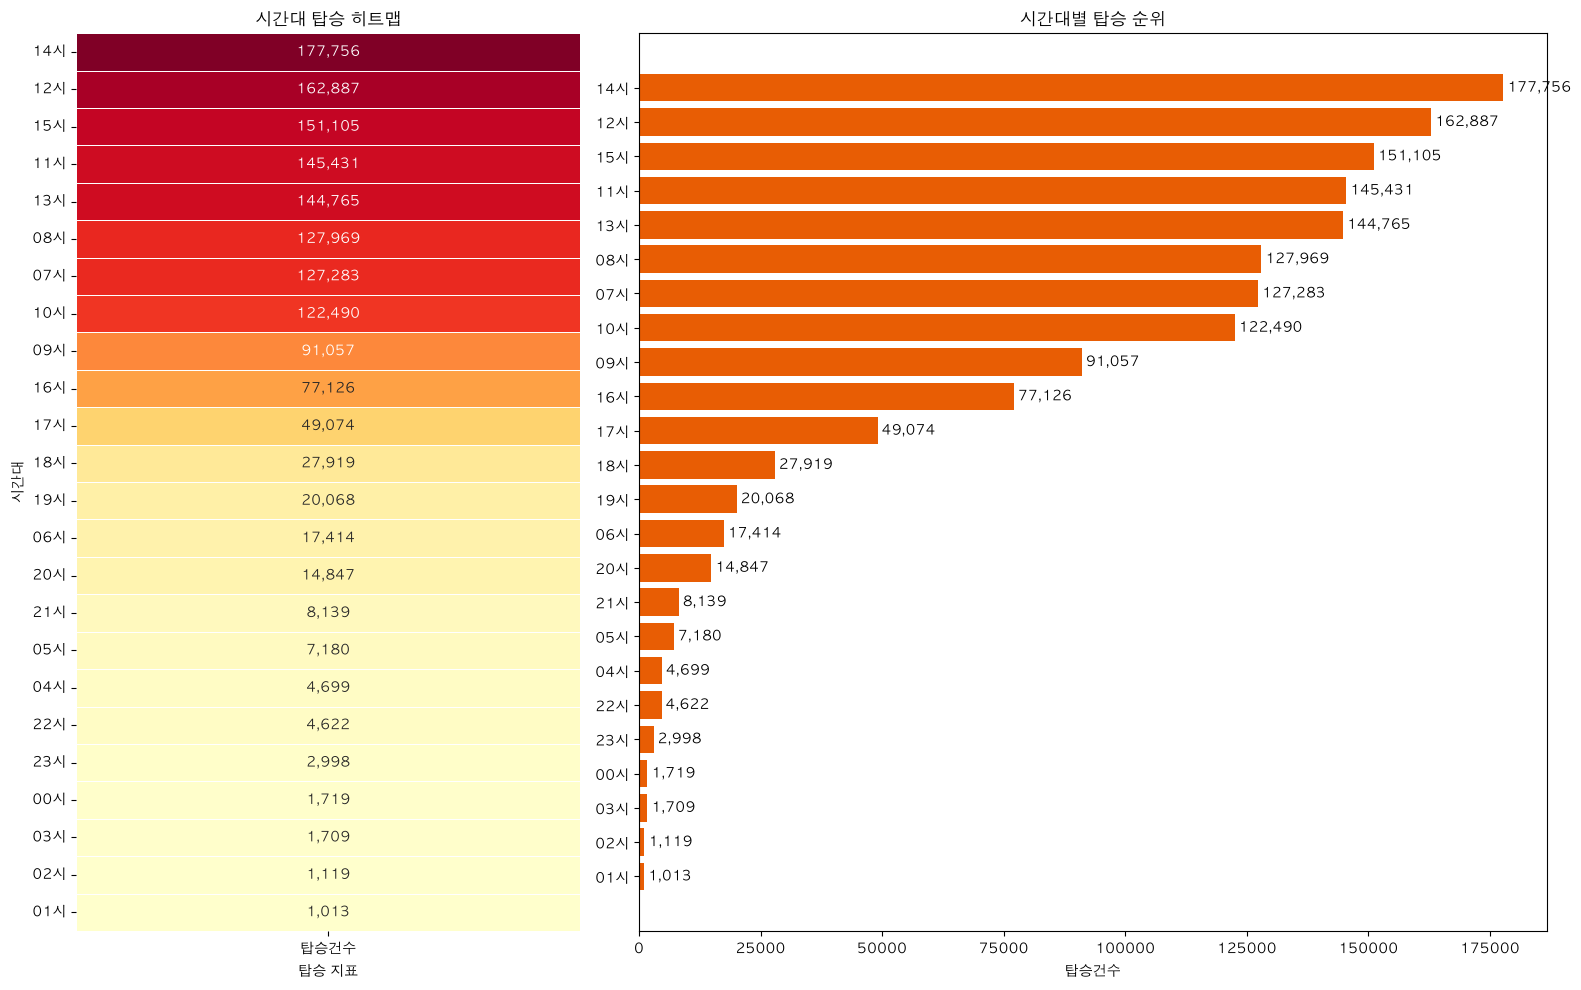

In [54]:
numeric_columns = df_boarding_demand.select_dtypes(include="number").columns
demand_column = numeric_columns[0]

heatmap_data = (
    df_boarding_demand.assign(
        시간=pd.to_datetime(
            df_boarding_demand["시간대"],
            format="%H:%M:%S",
        ).dt.hour
    )
    .groupby("시간")[demand_column]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

heatmap_data.index = [f"{hour:02d}시" for hour in heatmap_data.index]

fig, (ax_heatmap, ax_bar) = plt.subplots(
    1,
    2,
    figsize=(16, 10),
    gridspec_kw={"width_ratios": [1, 1.8]},
)

sns.heatmap(
    heatmap_data,
    ax=ax_heatmap,
    cmap="YlOrRd",
    annot=True,
    fmt=",.0f",
    linewidths=0.5,
    cbar=False,
)

ax_heatmap.set_title("시간대 탑승 히트맵")
ax_heatmap.set_xlabel("탑승 지표")
ax_heatmap.set_ylabel("시간대")
ax_heatmap.tick_params(axis="y", rotation=0)

ax_bar.barh(heatmap_data.index, heatmap_data[demand_column], color="#e85d04")
ax_bar.invert_yaxis()
ax_bar.set_title("시간대별 탑승 순위")
ax_bar.set_xlabel("탑승건수")
ax_bar.set_ylabel("")

for index, value in enumerate(heatmap_data[demand_column]):
    ax_bar.text(value, index, f" {value:,.0f}", va="center")

plt.tight_layout()
plt.show()

## 요일별 탑승 히트맵

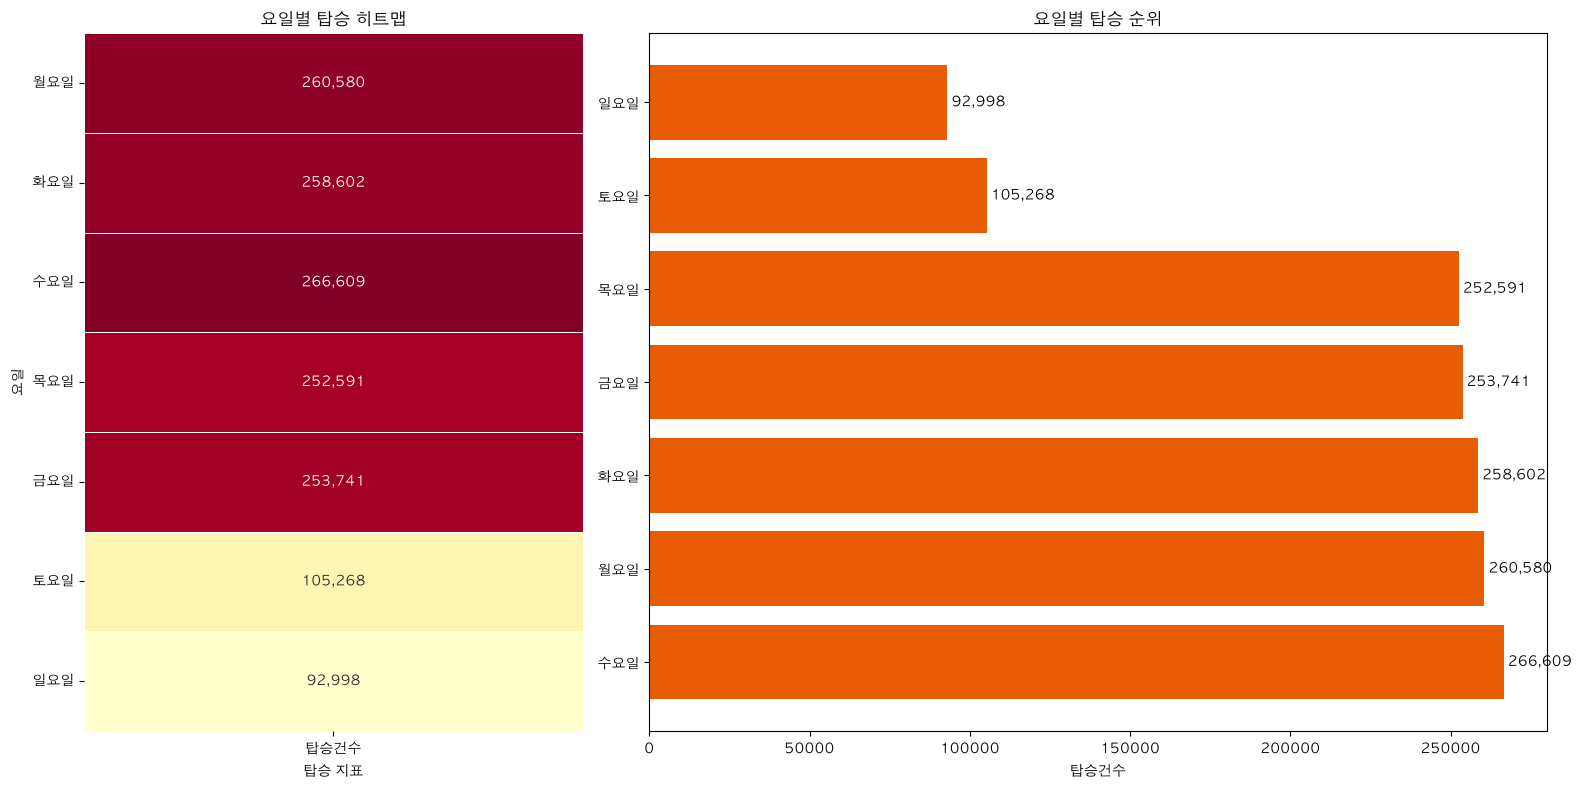

In [55]:
weekday_order = ["월요일", "화요일", "수요일", "목요일", "금요일", "토요일", "일요일"]

weekday_summary = (
    df_boarding_demand.assign(
        요일=pd.to_datetime(df_boarding_demand["일자"]).dt.dayofweek.map(
            dict(enumerate(weekday_order))
        )
    )
    .groupby("요일")[demand_column]
    .sum()
    .reindex(weekday_order)
    .to_frame(name="탑승건수")
)

fig, (ax_heatmap, ax_bar) = plt.subplots(
    1,
    2,
    figsize=(16, 8),
    gridspec_kw={"width_ratios": [1, 1.8]},
)

sns.heatmap(
    weekday_summary,
    ax=ax_heatmap,
    cmap="YlOrRd",
    annot=True,
    fmt=",.0f",
    linewidths=0.5,
    cbar=False,
)

ax_heatmap.set_title("요일별 탑승 히트맵")
ax_heatmap.set_xlabel("탑승 지표")
ax_heatmap.set_ylabel("요일")
ax_heatmap.tick_params(axis="y", rotation=0)

weekday_ranking = weekday_summary["탑승건수"].sort_values(ascending=True)

ax_bar.barh(weekday_ranking.index, weekday_ranking.values, color="#e85d04")
ax_bar.invert_yaxis()
ax_bar.set_title("요일별 탑승 순위")
ax_bar.set_xlabel("탑승건수")
ax_bar.set_ylabel("")

for index, value in enumerate(weekday_ranking.values):
    ax_bar.text(value, index, f" {value:,.0f}", va="center")

plt.tight_layout()
plt.show()

## 요일별 X 시간대별 탑승 히트맵

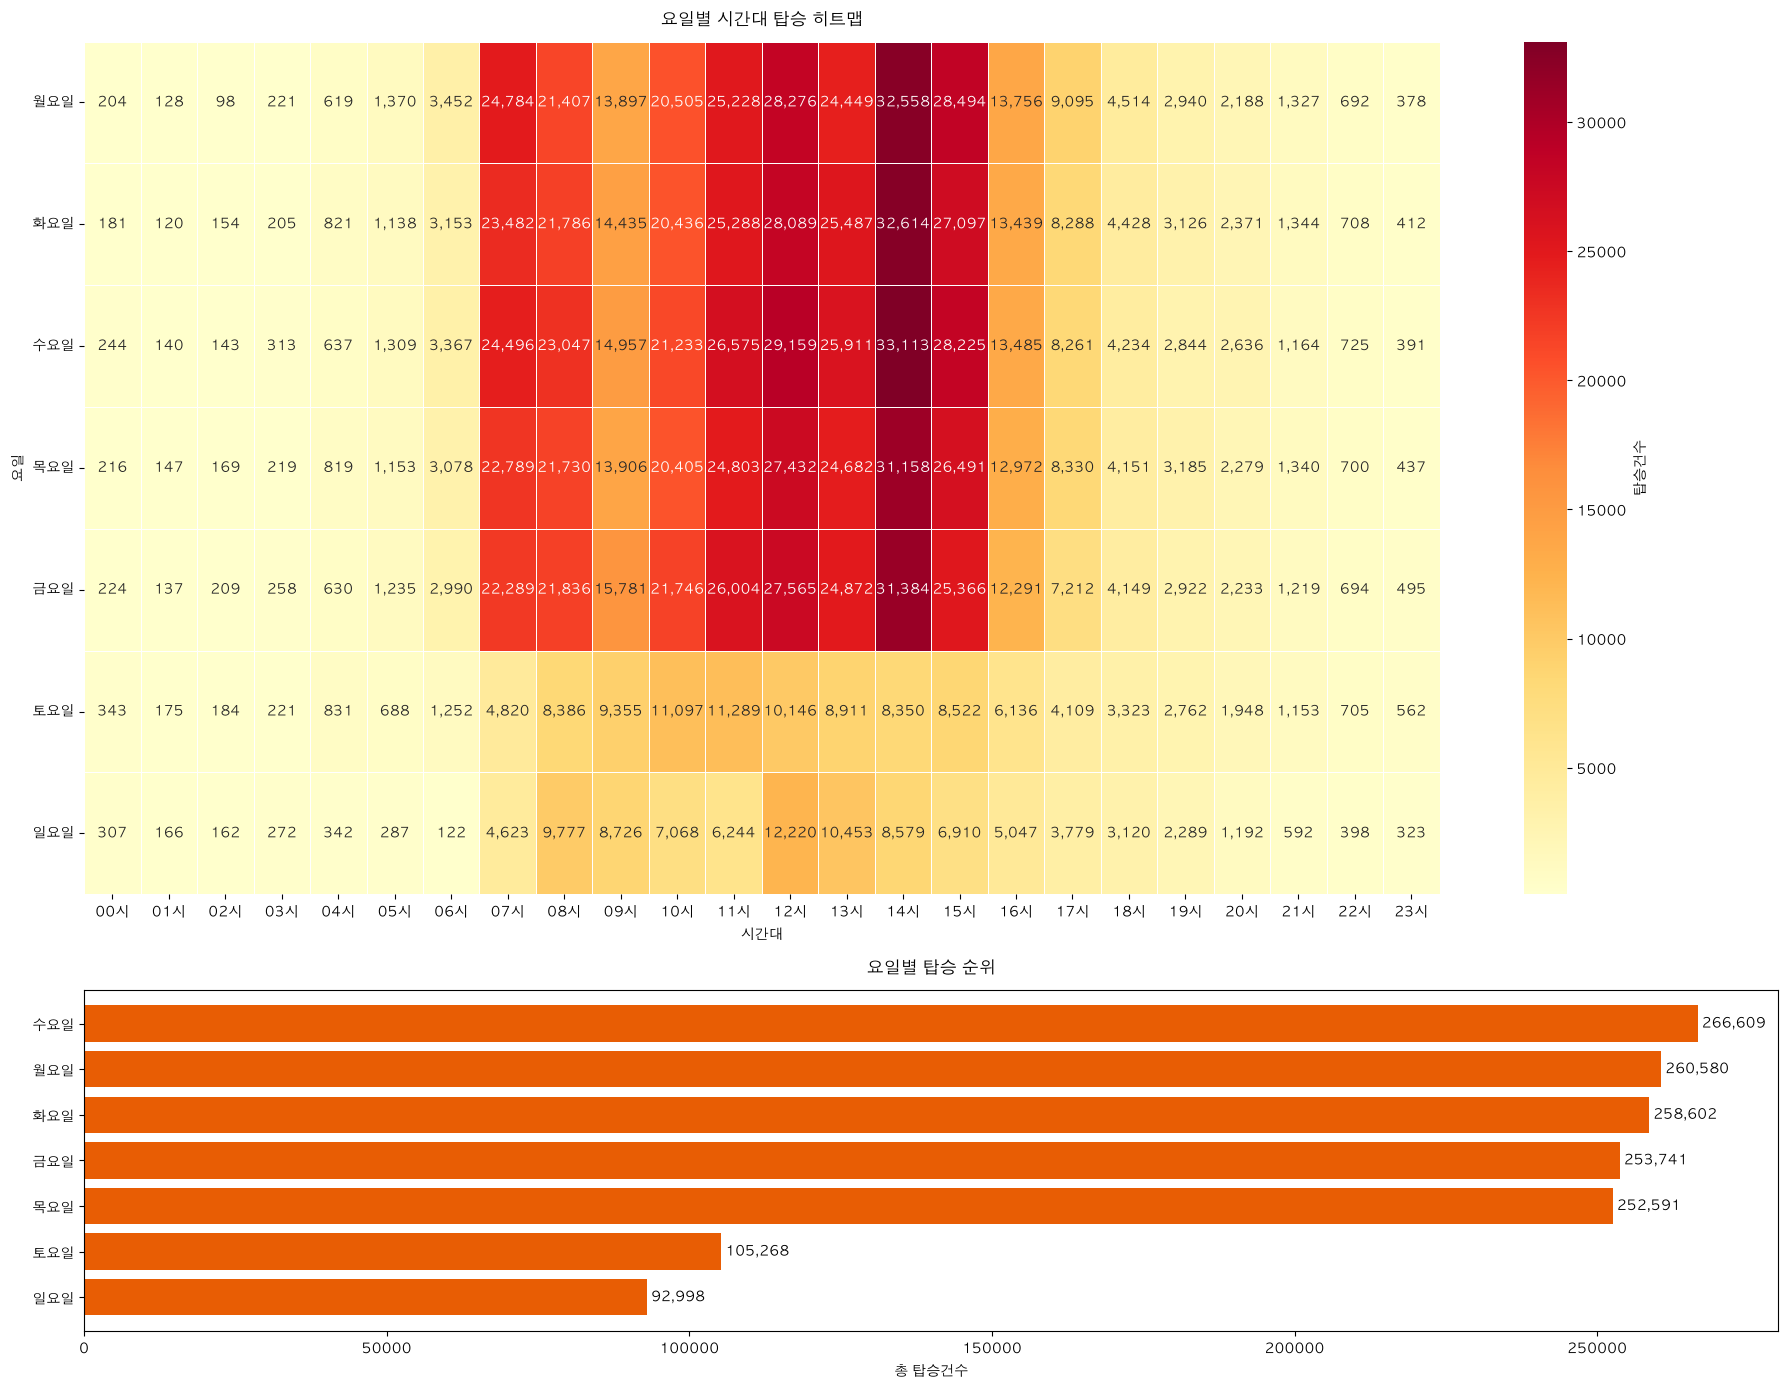

In [57]:
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
weekday_data = df_boarding_demand.assign(
    요일=pd.to_datetime(df_boarding_demand['일자']).dt.dayofweek.map(dict(enumerate(weekday_order))),
    시간=pd.to_datetime(df_boarding_demand['시간대'], format='%H:%M:%S').dt.hour,
)

weekday_heatmap = weekday_data.pivot_table(
    index='요일', columns='시간', values='탑승건수', aggfunc='sum'
).reindex(weekday_order)
weekday_heatmap.columns = [f'{hour:02d}시' for hour in weekday_heatmap.columns]
weekday_ranking = weekday_heatmap.sum(axis=1).sort_values(ascending=False)

fig, (ax_heatmap, ax_bar) = plt.subplots(
    2, 1, figsize=(18, 14), gridspec_kw={'height_ratios': [3.5, 1.4]}
)
sns.heatmap(
    weekday_heatmap,
    ax=ax_heatmap,
    cmap='YlOrRd',
    annot=True,
    fmt=',.0f',
    linewidths=0.5,
    cbar_kws={'label': '탑승건수'},
)
ax_heatmap.set_title('요일별 시간대 탑승 히트맵', pad=12)
ax_heatmap.set_xlabel('시간대')
ax_heatmap.set_ylabel('요일')
ax_heatmap.tick_params(axis='x', rotation=0)
ax_heatmap.tick_params(axis='y', rotation=0)

ax_bar.barh(weekday_ranking.index, weekday_ranking.values, color='#e85d04')
ax_bar.invert_yaxis()
ax_bar.set_title('요일별 탑승 순위', pad=12)
ax_bar.set_xlabel('총 탑승건수')
ax_bar.set_ylabel('')
for index, value in enumerate(weekday_ranking.values):
    ax_bar.text(value, index, f' {value:,.0f}', va='center')

plt.tight_layout()
plt.show()

## 요일 × 시간대별 탑승 비율 히트맵

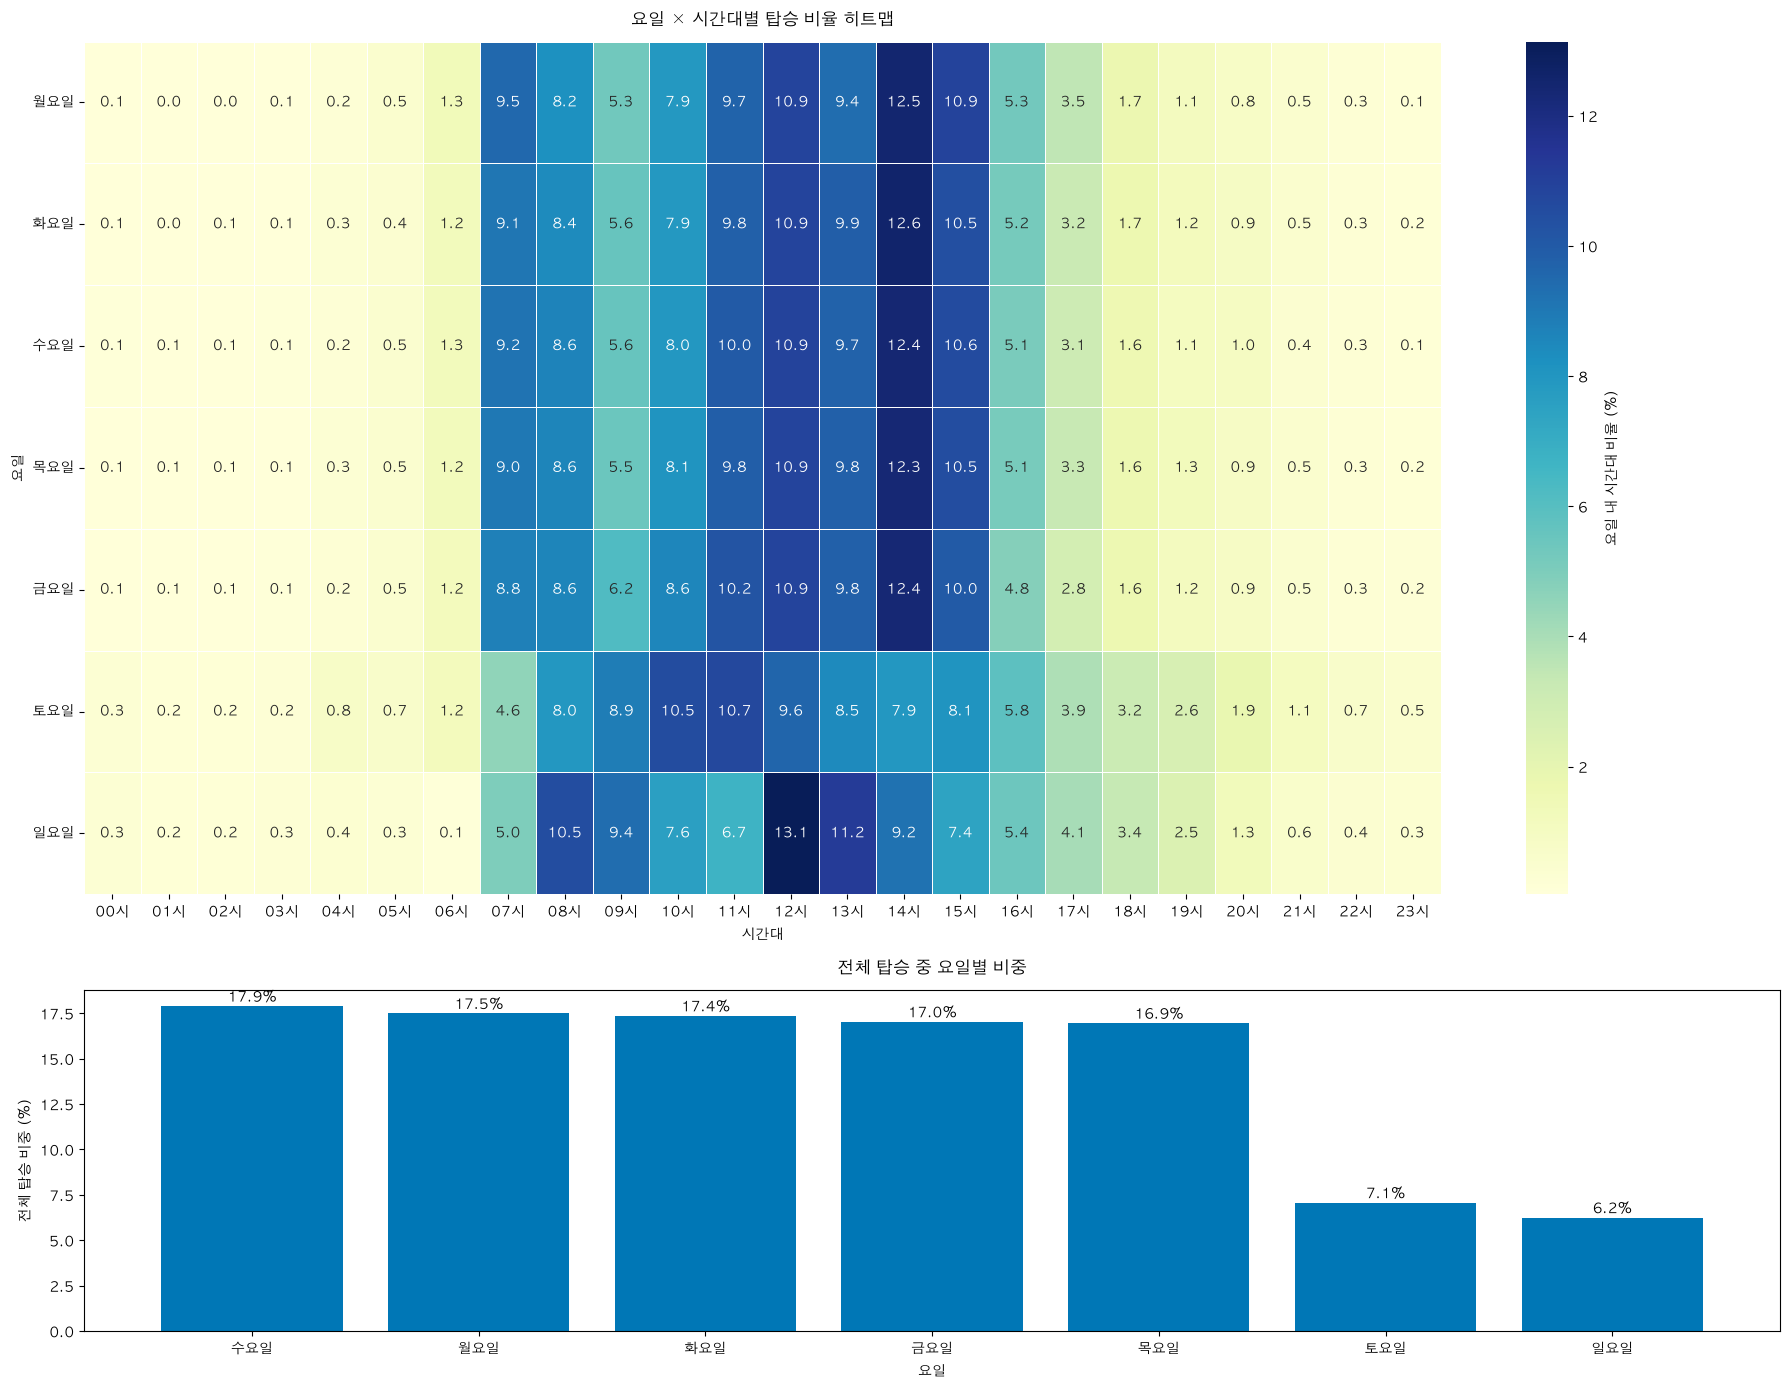

In [58]:
weekday_ratio = weekday_heatmap.div(weekday_heatmap.sum(axis=1), axis=0) * 100
weekday_total = weekday_heatmap.sum(axis=1)
weekday_share = (weekday_total / weekday_total.sum() * 100).sort_values(ascending=False)

fig, (ax_heatmap, ax_bar) = plt.subplots(
    2, 1, figsize=(18, 14), gridspec_kw={'height_ratios': [3.5, 1.4]}
)
sns.heatmap(
    weekday_ratio,
    ax=ax_heatmap,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': '요일 내 시간대 비율 (%)'},
)
ax_heatmap.set_title('요일 × 시간대별 탑승 비율 히트맵', pad=12)
ax_heatmap.set_xlabel('시간대')
ax_heatmap.set_ylabel('요일')
ax_heatmap.tick_params(axis='x', rotation=0)
ax_heatmap.tick_params(axis='y', rotation=0)

ax_bar.bar(weekday_share.index, weekday_share.values, color='#0077b6')
ax_bar.set_title('전체 탑승 중 요일별 비중', pad=12)
ax_bar.set_xlabel('요일')
ax_bar.set_ylabel('전체 탑승 비중 (%)')
ax_bar.tick_params(axis='x', rotation=0)
for index, value in enumerate(weekday_share.values):
    ax_bar.text(index, value, f'{value:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 탑승 집계 CSV 생성


In [59]:
# 1. 공통 준비

import pandas as pd
from pathlib import Path

input_path = Path('../data/raw/서울시설공단_장애인콜택시 시간대별 탑승건수_20251231.csv')
output_dir = Path('../data/processed')
output_dir.mkdir(exist_ok=True)

weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
weekday_map = dict(enumerate(weekday_order))

df_boarding_hour = pd.read_csv(input_path)

df_boarding_hour['일자'] = pd.to_datetime(df_boarding_hour['일자'], errors='coerce')
df_boarding_hour['요일'] = df_boarding_hour['일자'].dt.dayofweek.map(weekday_map)
df_boarding_hour['시간'] = pd.to_datetime(
    df_boarding_hour['시간대'],
    format='%H:%M:%S',
    errors='coerce'
).dt.hour
df_boarding_hour['시간대_label'] = df_boarding_hour['시간'].map(
    lambda x: f'{int(x):02d}시' if pd.notna(x) else pd.NA
)

total_service_days = df_boarding_hour['일자'].dropna().dt.date.nunique()

weekday_service_days = (
    df_boarding_hour[['일자', '요일']]
    .dropna()
    .drop_duplicates()
    .groupby('요일')
    .size()
    .reindex(weekday_order)
    .rename('운행일수')
)

hour_columns = [f'{hour:02d}시' for hour in range(24)]

print('공통 준비 완료')
print(f'전체 운행일수: {total_service_days}')
print(weekday_service_days)

공통 준비 완료
전체 운행일수: 365
요일
월요일    52
화요일    52
수요일    53
목요일    52
금요일    52
토요일    52
일요일    52
Name: 운행일수, dtype: int64


In [60]:
# 2. 요일별_전체_탑승건수.csv 생성

weekday_total = (
    df_boarding_hour.groupby('요일', as_index=False)['탑승건수']
    .sum()
)

weekday_total['요일'] = pd.Categorical(
    weekday_total['요일'],
    categories=weekday_order,
    ordered=True
)

weekday_total = weekday_total.sort_values('요일').reset_index(drop=True)

output_path = output_dir / '요일별_전체_탑승건수.csv'
weekday_total.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'저장 완료: {output_path}')
weekday_total

저장 완료: ../data/processed/요일별_전체_탑승건수.csv


,요일,탑승건수
0,월요일,260580
1,화요일,258602
2,수요일,266609
3,목요일,252591
4,금요일,253741
5,토요일,105268
6,일요일,92998


In [61]:
# 3. 시간대별_전체_탑승건수.csv 생성

hour_total = (
    df_boarding_hour.groupby(['시간', '시간대_label'], as_index=False)['탑승건수']
    .sum()
    .sort_values('시간')
    .reset_index(drop=True)
)

hour_total_csv = (
    hour_total[['시간대_label', '탑승건수']]
    .rename(columns={'시간대_label': '시간대'})
)

output_path = output_dir / '시간대별_전체_탑승건수.csv'
hour_total_csv.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'저장 완료: {output_path}')
hour_total_csv

저장 완료: ../data/processed/시간대별_전체_탑승건수.csv


,시간대,탑승건수
0,00시,1719
1,01시,1013
2,02시,1119
3,03시,1709
4,04시,4699
5,05시,7180
6,06시,17414
7,07시,127283
8,08시,127969
9,09시,91057


In [62]:
# 4. 요일X시간대별_전체_탑승건수.csv 생성

weekday_hour_total = (
    df_boarding_hour.pivot_table(
        index='요일',
        columns='시간대_label',
        values='탑승건수',
        aggfunc='sum',
        fill_value=0
    )
    .reindex(weekday_order)
)

weekday_hour_total = weekday_hour_total[
    [col for col in hour_columns if col in weekday_hour_total.columns]
]

weekday_hour_total.index.name = '요일'

output_path = output_dir / '요일X시간대별_전체_탑승건수.csv'
weekday_hour_total.to_csv(output_path, encoding='utf-8-sig')

print(f'저장 완료: {output_path}')
weekday_hour_total

저장 완료: ../data/processed/요일X시간대별_전체_탑승건수.csv


시간대_label,00시,01시,02시,03시,04시,05시,06시,07시,08시,09시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
요일,,,,,,,,,,,,,,,,,,,,,
월요일,204,128,98,221,619,1370,3452,24784,21407,13897,...,32558,28494,13756,9095,4514,2940,2188,1327,692,378
화요일,181,120,154,205,821,1138,3153,23482,21786,14435,...,32614,27097,13439,8288,4428,3126,2371,1344,708,412
수요일,244,140,143,313,637,1309,3367,24496,23047,14957,...,33113,28225,13485,8261,4234,2844,2636,1164,725,391
목요일,216,147,169,219,819,1153,3078,22789,21730,13906,...,31158,26491,12972,8330,4151,3185,2279,1340,700,437
금요일,224,137,209,258,630,1235,2990,22289,21836,15781,...,31384,25366,12291,7212,4149,2922,2233,1219,694,495
토요일,343,175,184,221,831,688,1252,4820,8386,9355,...,8350,8522,6136,4109,3323,2762,1948,1153,705,562
일요일,307,166,162,272,342,287,122,4623,9777,8726,...,8579,6910,5047,3779,3120,2289,1192,592,398,323


In [63]:
# 5. 요일별_일평균_탑승건수.csv 생성

weekday_total_series = (
    df_boarding_hour.groupby('요일')['탑승건수']
    .sum()
    .reindex(weekday_order)
    .rename('총탑승건수')
)

weekday_daily_avg = pd.concat(
    [weekday_service_days, weekday_total_series],
    axis=1
)

weekday_daily_avg['일평균탑승건수'] = (
    weekday_daily_avg['총탑승건수'] / weekday_daily_avg['운행일수']
)

weekday_daily_avg = (
    weekday_daily_avg
    .reset_index()
    .rename(columns={'index': '요일'})
)

output_path = output_dir / '요일별_일평균_탑승건수.csv'
weekday_daily_avg.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'저장 완료: {output_path}')
weekday_daily_avg

저장 완료: ../data/processed/요일별_일평균_탑승건수.csv


,요일,운행일수,총탑승건수,일평균탑승건수
0,월요일,52,260580,5011.153846
1,화요일,52,258602,4973.115385
2,수요일,53,266609,5030.358491
3,목요일,52,252591,4857.519231
4,금요일,52,253741,4879.634615
5,토요일,52,105268,2024.384615
6,일요일,52,92998,1788.423077


In [64]:
# 6. 시간대별_일평균_탑승건수.csv 생성

hour_total = (
    df_boarding_hour.groupby(['시간', '시간대_label'], as_index=False)['탑승건수']
    .sum()
    .sort_values('시간')
    .reset_index(drop=True)
)

hour_daily_avg = (
    hour_total[['시간대_label', '탑승건수']]
    .rename(columns={
        '시간대_label': '시간대',
        '탑승건수': '총탑승건수'
    })
)

hour_daily_avg['운행일수'] = total_service_days
hour_daily_avg['일평균탑승건수'] = (
    hour_daily_avg['총탑승건수'] / hour_daily_avg['운행일수']
)

hour_daily_avg = hour_daily_avg[
    ['시간대', '운행일수', '총탑승건수', '일평균탑승건수']
]

output_path = output_dir / '시간대별_일평균_탑승건수.csv'
hour_daily_avg.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'저장 완료: {output_path}')
hour_daily_avg

저장 완료: ../data/processed/시간대별_일평균_탑승건수.csv


,시간대,운행일수,총탑승건수,일평균탑승건수
0,00시,365,1719,4.709589
1,01시,365,1013,2.775342
2,02시,365,1119,3.065753
3,03시,365,1709,4.682192
4,04시,365,4699,12.873973
5,05시,365,7180,19.671233
6,06시,365,17414,47.709589
7,07시,365,127283,348.720548
8,08시,365,127969,350.600000
9,09시,365,91057,249.471233


In [65]:
# 7. 요일X시간대별_일평균_탑승건수.csv 생성

weekday_hour_total = (
    df_boarding_hour.pivot_table(
        index='요일',
        columns='시간대_label',
        values='탑승건수',
        aggfunc='sum',
        fill_value=0
    )
    .reindex(weekday_order)
)

weekday_hour_total = weekday_hour_total[
    [col for col in hour_columns if col in weekday_hour_total.columns]
]

weekday_hour_daily_avg = weekday_hour_total.div(
    weekday_service_days,
    axis=0
)

weekday_hour_daily_avg.index.name = '요일'

output_path = output_dir / '요일X시간대별_일평균_탑승건수.csv'
weekday_hour_daily_avg.to_csv(output_path, encoding='utf-8-sig')

print(f'저장 완료: {output_path}')
weekday_hour_daily_avg

저장 완료: ../data/processed/요일X시간대별_일평균_탑승건수.csv


시간대_label,00시,01시,02시,03시,04시,05시,06시,07시,08시,09시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
요일,,,,,,,,,,,,,,,,,,,,,
월요일,3.923077,2.461538,1.884615,4.250000,11.903846,26.346154,66.384615,476.615385,411.673077,267.250000,...,626.115385,547.961538,264.538462,174.903846,86.807692,56.538462,42.076923,25.519231,13.307692,7.269231
화요일,3.480769,2.307692,2.961538,3.942308,15.788462,21.884615,60.634615,451.576923,418.961538,277.596154,...,627.192308,521.096154,258.442308,159.384615,85.153846,60.115385,45.596154,25.846154,13.615385,7.923077
수요일,4.603774,2.641509,2.698113,5.905660,12.018868,24.698113,63.528302,462.188679,434.849057,282.207547,...,624.773585,532.547170,254.433962,155.867925,79.886792,53.660377,49.735849,21.962264,13.679245,7.377358
목요일,4.153846,2.826923,3.250000,4.211538,15.750000,22.173077,59.192308,438.250000,417.884615,267.423077,...,599.192308,509.442308,249.461538,160.192308,79.826923,61.250000,43.826923,25.769231,13.461538,8.403846
금요일,4.307692,2.634615,4.019231,4.961538,12.115385,23.750000,57.500000,428.634615,419.923077,303.480769,...,603.538462,487.807692,236.365385,138.692308,79.788462,56.192308,42.942308,23.442308,13.346154,9.519231
토요일,6.596154,3.365385,3.538462,4.250000,15.980769,13.230769,24.076923,92.692308,161.269231,179.903846,...,160.576923,163.884615,118.000000,79.019231,63.903846,53.115385,37.461538,22.173077,13.557692,10.807692
일요일,5.903846,3.192308,3.115385,5.230769,6.576923,5.519231,2.346154,88.903846,188.019231,167.807692,...,164.980769,132.884615,97.057692,72.673077,60.000000,44.019231,22.923077,11.384615,7.653846,6.211538
